<a href="https://colab.research.google.com/github/archthegit/adaptive-visual-processing/blob/main/colab/vqa_experiment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 !git clone https://github.com/archthegit/adaptive-visual-processing.git

Cloning into 'adaptive-visual-processing'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 79 (delta 13), reused 68 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 57.94 KiB | 1.32 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [ ]:
%cd adaptive-visual-processing/

/content/adaptive-visual-processing


In [ ]:
%pip install -r requirements.txt

In [ ]:
%pip install -r requirements-qwen.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 80.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


In [ ]:
!python scripts/download_manifest_videos.py \
    --manifest outputs/experiment1_manifest.jsonl \
    --output-dir data/hd_epic_mp4 \
    --video-id P03-20240217-094713

Manifest videos: 1
Already present: 0
Missing: 1
Known total size: 106.5 MiB
Unknown size count: 0
Plan JSON: outputs/manifest_video_download_plan.json
Dry-run only. Re-run with --yes to download missing videos.


In [ ]:
!git clone https://github.com/hd-epic/hd-epic-annotations.git /content/hd-epic-annotations

Cloning into '/content/hd-epic-annotations'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 184 (delta 51), reused 32 (delta 31), pack-reused 115 (from 1)
Receiving objects: 100% (184/184), 18.52 MiB | 18.08 MiB/s, done.
Resolving deltas: 100% (79/79), done.


In [ ]:
!python scripts/run_experiment1.py \
    --questions-dir /content/hd-epic-annotations/vqa-benchmark \
    --mp4-dir data/hd_epic_mp4 \
    --manifest outputs/experiment1_manifest.jsonl \
    --question-id fine_grained_why_recognition_36 \
    --num-frames 4 \
    --resolution-config low \
    --vision-access-through-layer none \
    --query-scope question \
    --output-dir outputs/experiment1_qwen_debug_one \
    --allow-7b-inference

{
  "num_records": 1,
  "output_jsonl": "outputs/experiment1_qwen_debug_one/records.jsonl",
  "runtime_seconds": 0.12593317031860352,
  "config": {
    "manifest": "outputs/experiment1_manifest.jsonl",
    "num_frames": 4,
    "resolution": {
      "name": "low",
      "min_pixels": 100352,
      "max_pixels": 200704,
      "description": "Small visual-token budget for debugging."
    },
    "vision_access_through_layer": "none",
    "query_scope": "question",
    "dry_run": false,
    "allow_7b_inference": true
  }
}


In [ ]:
!cat outputs/experiment1_qwen_debug_one/records.jsonl

{"question_id": "fine_grained_why_recognition_36", "category": "fine_grained", "question_type": "fine_grained_why_recognition", "status": "failed", "error": "data/hd_epic_mp4/P03/P03-20240217-094713.mp4"}


In [ ]:
!ls -lh data/hd_epic_mp4/P03/

ls: cannot access 'data/hd_epic_mp4/P03/': No such file or directory


In [ ]:
!python scripts/download_manifest_videos.py --manifest outputs/experiment1_manifest.jsonl --output-dir data/hd_epic_mp4 --video-id P03-20240217-094713 --yes

Manifest videos: 1
Already present: 0
Missing: 1
Known total size: 106.5 MiB
Unknown size count: 0
Plan JSON: outputs/manifest_video_download_plan.json
[1/1] downloading P03-20240217-094713 (106.5 MiB)


In [ ]:
!ls -lh data/hd_epic_mp4/P03/P03-20240217-094713.mp4

-rw-r--r-- 1 root root 107M Aug  9 00:34 data/hd_epic_mp4/P03/P03-20240217-094713.mp4


In [ ]:
!python scripts/run_experiment1.py --questions-dir /content/hd-epic-annotations/vqa-benchmark --mp4-dir data/hd_epic_mp4 --manifest outputs/experiment1_manifest.jsonl --question-id fine_grained_why_recognition_36 --num-frames 4 --resolution-config low --vision-access-through-layer none --query-scope question --output-dir outputs/experiment1_qwen_debug_one --allow-7b-inference

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files: 100% 5/5 [00:00<00:00, 10661.68it/s]
Download complete: :           |  0.00B            
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Loading weights: 100% 729/729 [00:04<00:00, 176.21it/s]
{
  "num_records": 1,
  "output_jsonl": "outputs/experiment1_qwen_debug_one/records.jsonl",
  "runtime_seconds": 24.948940992355347,
  "config": {
    "manifest": "outputs/experiment1_manifest.jsonl",
    "num_frames": 4,
    "resolution": {
      "name": "low",
      "min_pixels": 100352,
      "max_pixels": 200704,
      "description": "Small visual-token budget for debugging."
    },
    "vision_access_through_layer": "none",
    "query_scope": "question",
    "max_new_tokens": 16,
    "dry_run": false,
    "allow_7b_inference": true
  }
}


In [ ]:
!cat outputs/experiment1_qwen_debug_one/records.jsonl

{"question_id": "fine_grained_why_recognition_36", "category": "fine_grained", "question_type": "fine_grained_why_recognition", "status": "complete", "artifact": "outputs/experiment1_qwen_debug_one/fine_grained_why_recognition_36.json", "correct": true, "predicted_idx": 2, "num_visual_tokens": 512}


In [ ]:
!git pull

remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 11 (delta 8), reused 11 (delta 8), pack-reused 0 (from 0)
Unpacking objects: 100% (11/11), 1.19 KiB | 608.00 KiB/s, done.
From https://github.com/archthegit/adaptive-visual-processing
   ed29953..95d2bf3  main       -> origin/main
Updating ed29953..95d2bf3
Fast-forward
 scripts/run_experiment1.py        |  6 ++++--
 src/models/base.py                |  3 ++-
 src/models/qwen.py                |  2 +-
 tests/test_answer_parsing.py      |  1 +
 tests/test_run_experiment1_cli.py | 10 ++++++++++
 5 files changed, 18 insertions(+), 4 deletions(-)
 create mode 100644 tests/test_run_experiment1_cli.py


In [ ]:
!cat outputs/experiment1_qwen_debug_one/fine_grained_why_recognition_36.json

Streaming output truncated to the last 5000 lines.
            0.0007799905421264049,
            0.00044073002464244934,
            0.0014533274644948754,
            0.0001401866441028609,
            0.0002825324210138955,
            0.0001647633853348296,
            4.351795990509214e-05,
            0.00025276474142012505,
            0.00011536203682126087
          ],
          [
            0.0001494580853899664,
            0.0003441562242213865,
            6.869065833756813e-05,
            0.00025884689350539843,
            0.0007938138538212819,
            0.00028477665544644824,
            0.00017938375027305703,
            0.0018810941049131583,
            0.0027603934982597927,
            0.0023899833743283726,
            0.0019356072186079976,
            0.0012088468591056295,
            0.00427844910691625,
            0.0001738452569495507,
            0.0001488511812783293,
            4.303975028516644e-05
          ],
          [
            0.00258371

In [ ]:
!python -c "import json; d=json.load(open('outputs/experiment1_qwen_debug_one/fine_grained_why_recognition_36.json')); print('raw_response:', repr(d['raw_response'])); print('predicted_idx:', d['predicted_idx']); print('correct_idx:', d['correct_idx']); print('correct_answer:', d['correct_answer']); print('choices:', d['choices'])"

raw_response: 'C'
predicted_idx: 2
correct_idx: 2
correct_answer: to wash blueberries more thoroughly.
choices: ['to brew the coffee.', 'to add to the rinsing water inside the bowl.', 'to wash blueberries more thoroughly.', 'to measure the cocoa.', 'to brew coffee.']


## Tiny Batch Debug Run

  Run a small 3-example Qwen2.5-VL Experiment 1 batch using low resolution and 4 sampled frames. This checks that video download, frame sampling, Qwen inference,
  answer parsing, token-layout mapping, and layer-wise relevance extraction work repeatedly before scaling to the full pilot.

In [38]:
!python scripts/download_manifest_videos.py --manifest outputs/experiment1_manifest.jsonl --output-dir data/hd_epic_mp4 --limit-videos 3 --yes

Manifest videos: 3
Already present: 0
Missing: 3
Known total size: 4.5 GiB
Unknown size count: 0
Plan JSON: outputs/manifest_video_download_plan.json
[1/3] downloading P01-20240203-130505 (824.6 MiB)
[2/3] downloading P01-20240203-135502 (2.3 GiB)
[3/3] downloading P01-20240203-184214 (1.4 GiB)
Traceback (most recent call last):
  File "/content/adaptive-visual-processing/scripts/download_manifest_videos.py", line 43, in download_file
    shutil.copyfileobj(response, handle)
  File "/usr/lib/python3.12/shutil.py", line 203, in copyfileobj
    while buf := fsrc_read(length):
                 ^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/http/client.py", line 484, in read
    s = self.fp.read(amt)
        ^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ssl.py", line 1251, in recv_into
    return self.read(nbytes, buffer)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  

In [48]:
!python scripts/run_experiment1.py \
    --questions-dir /content/hd-epic-annotations/vqa-benchmark \
    --mp4-dir data/hd_epic_mp4 \
    --manifest outputs/experiment1_manifest.jsonl \
    --question-id fine_grained_how_recognition_414 \
    --question-id ingredient_ingredients_order_10 \
    --question-id ingredient_ingredients_order_44 \
    --num-frames 4 \
    --resolution-config low \
    --vision-access-through-layer none \
    --query-scope question \
    --max-new-tokens 16 \
    --output-dir outputs/experiment1_qwen_debug_3_downloaded \
    --allow-7b-inference

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files: 100% 5/5 [00:00<00:00, 40407.55it/s]
Download complete: :           |  0.00B            
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Loading weights: 100% 729/729 [00:04<00:00, 175.49it/s]
{
  "num_records": 3,
  "output_jsonl": "outputs/experiment1_qwen_debug_3_downloaded/records.jsonl",
  "runtime_seconds": 33.042203426361084,
  "config": {
    "manifest": "outputs/experiment1_manifest.jsonl",
    "num_frames": 4,
    "resolution": {
      "name": "low",
      "min_pixels": 100352,
      "max_pixels": 200704,
      "description": "Small visual-token budget for debugging."
    },
    "vision_access_through_layer": "none",
    "query_scope": "question",
    "max_new_tokens": 16,
    "dry_run": false,
    "allow_7b_inference": true
  }
}


In [49]:
!cat outputs/experiment1_qwen_debug_3_downloaded/records.jsonl

{"question_id": "fine_grained_how_recognition_414", "category": "fine_grained", "question_type": "fine_grained_how_recognition", "status": "complete", "artifact": "outputs/experiment1_qwen_debug_3_downloaded/fine_grained_how_recognition_414.json", "correct": false, "predicted_idx": 4, "num_visual_tokens": 512}
{"question_id": "ingredient_ingredients_order_10", "category": "ingredient", "question_type": "ingredient_ingredients_order", "status": "complete", "artifact": "outputs/experiment1_qwen_debug_3_downloaded/ingredient_ingredients_order_10.json", "correct": false, "predicted_idx": 1, "num_visual_tokens": 512}
{"question_id": "ingredient_ingredients_order_44", "category": "ingredient", "question_type": "ingredient_ingredients_order", "status": "complete", "artifact": "outputs/experiment1_qwen_debug_3_downloaded/ingredient_ingredients_order_44.json", "correct": false, "predicted_idx": 1, "num_visual_tokens": 512}


In [50]:
!python -c "import json; vids={'P01-20240203-130505','P01-20240203-135502','P01-20240203-184214'}; \
  rows=[json.loads(l) for l in open('outputs/experiment1_manifest.jsonl') if l.strip()]; \
  [print(r['question_id'], r['category'], r['question_type'], [c.get('video_id') for c in r.get('video_clip', [])]) for r in rows if any(c.get('video_id') in vids for c in r.get('video_clip', []))]"

fine_grained_how_recognition_414 fine_grained fine_grained_how_recognition ['P01-20240203-184214']
ingredient_ingredients_order_10 ingredient ingredient_ingredients_order ['P01-20240203-135502']
ingredient_ingredients_order_44 ingredient ingredient_ingredients_order ['P01-20240203-130505']


In [46]:
!find data -name 'P01-20240203-184214*' -ls

  3298509 902596 -rw-r--r--   1 root     root     924254208 Aug  9 02:29 data/hd_epic_mp4/P01/P01-20240203-184214.mp4.part


In [47]:
!python scripts/download_manifest_videos.py \
    --manifest outputs/experiment1_manifest.jsonl \
    --output-dir data/hd_epic_mp4 \
    --video-id P01-20240203-184214 \
    --yes

Manifest videos: 1
Already present: 0
Missing: 1
Known total size: 1.4 GiB
Unknown size count: 0
Plan JSON: outputs/manifest_video_download_plan.json
[1/1] downloading P01-20240203-184214 (1.4 GiB)


## Full Pilot Video Prep

In [51]:
!python scripts/download_manifest_videos.py \
    --manifest outputs/experiment1_manifest.jsonl \
    --output-dir data/hd_epic_mp4 \
    --dry-run

Manifest videos: 72
Already present: 4
Missing: 68
Known total size: 70.1 GiB
Unknown size count: 0
Plan JSON: outputs/manifest_video_download_plan.json
Dry-run only. Re-run with --yes to download missing videos.


## Build Video-Aware Mini Pilot

In [57]:
!git pull

remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 7 (delta 5), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 759 bytes | 379.00 KiB/s, done.
From https://github.com/archthegit/adaptive-visual-processing
   6244ca8..6834a89  main       -> origin/main
Updating 6244ca8..6834a89
Fast-forward
 src/experiment1/qwen_execution.py | 2 +-
 tests/test_qwen_execution.py      | 4 ++++
 2 files changed, 5 insertions(+), 1 deletion(-)


In [53]:
!python scripts/create_video_aware_experiment1_manifest.py \
    --questions-dir /content/hd-epic-annotations/vqa-benchmark \
    --mp4-dir data/hd_epic_mp4 \
    --target-size 12 \
    --max-new-videos 8 \
    --seed 20260808 \
    --output-jsonl outputs/experiment1_video_aware_manifest.jsonl \
    --summary-json outputs/experiment1_video_aware_summary.json


{
  "target_size": 12,
  "actual_size": 12,
  "max_new_videos": 8,
  "seed": 20260808,
  "preferred_video_count": 4,
  "preferred_videos_used": [
    "P01-20240203-130505",
    "P01-20240203-135502",
    "P01-20240203-184214"
  ],
  "available_question_types": {
    "fine_grained": [
      "fine_grained_action_localization",
      "fine_grained_action_recognition",
      "fine_grained_how_recognition",
      "fine_grained_why_recognition"
    ],
    "gaze": [
      "gaze_gaze_estimation",
      "gaze_interaction_anticipation"
    ],
    "ingredient": [
      "ingredient_exact_ingredient_recognition",
      "ingredient_ingredient_adding_localization",
      "ingredient_ingredient_recognition",
      "ingredient_ingredient_retrieval",
      "ingredient_ingredient_weight",
      "ingredient_ingredients_order"
    ],
    "object_motion": [
      "object_motion_object_movement_counting",
      "object_motion_object_movement_itinerary",
      "object_motion_stationary_object_localization"
  

In [54]:
!python scripts/download_manifest_videos.py \
    --manifest outputs/experiment1_video_aware_manifest.jsonl \
    --output-dir data/hd_epic_mp4 \
    --dry-run

Manifest videos: 3
Already present: 3
Missing: 0
Known total size: 4.5 GiB
Unknown size count: 0
Plan JSON: outputs/manifest_video_download_plan.json
Dry-run only. Re-run with --yes to download missing videos.


In [58]:
!python scripts/run_experiment1.py \
    --questions-dir /content/hd-epic-annotations/vqa-benchmark \
    --mp4-dir data/hd_epic_mp4 \
    --manifest outputs/experiment1_video_aware_manifest.jsonl \
    --num-frames 4 \
    --resolution-config low \
    --vision-access-through-layer none \
    --query-scope question \
    --max-new-tokens 16 \
    --output-dir outputs/experiment1_qwen_video_aware_low_f4 \
    --allow-7b-inference

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files: 100% 5/5 [00:00<00:00, 43062.67it/s]
Download complete: :           |  0.00B            
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Loading weights: 100% 729/729 [00:04<00:00, 176.58it/s]
{
  "num_records": 12,
  "output_jsonl": "outputs/experiment1_qwen_video_aware_low_f4/records.jsonl",
  "runtime_seconds": 84.78385853767395,
  "config": {
    "manifest": "outputs/experiment1_video_aware_manifest.jsonl",
    "num_frames": 4,
    "resolution": {
      "name": "low",
      "min_pixels": 100352,
      "max_pixels": 200704,
      "description": "Small visual-token budget for debugging."
    },
    "vision_access_through_layer": "none",
    "query_scope": "question",
    "max_new_tokens": 16,
    "dry_run": false,
    "allow_7b_inference": true
  }
}


In [59]:
!cat outputs/experiment1_qwen_video_aware_low_f4/records.jsonl

{"question_id": "fine_grained_action_localization_1309", "category": "fine_grained", "question_type": "fine_grained_action_localization", "status": "complete", "artifact": "outputs/experiment1_qwen_video_aware_low_f4/fine_grained_action_localization_1309.json", "correct": false, "predicted_idx": 3, "num_visual_tokens": 512}
{"question_id": "fine_grained_action_localization_4186", "category": "fine_grained", "question_type": "fine_grained_action_localization", "status": "complete", "artifact": "outputs/experiment1_qwen_video_aware_low_f4/fine_grained_action_localization_4186.json", "correct": false, "predicted_idx": 3, "num_visual_tokens": 512}
{"question_id": "fine_grained_action_localization_6299", "category": "fine_grained", "question_type": "fine_grained_action_localization", "status": "complete", "artifact": "outputs/experiment1_qwen_video_aware_low_f4/fine_grained_action_localization_6299.json", "correct": false, "predicted_idx": 1, "num_visual_tokens": 512}
{"question_id": "gaze_

## Summarize Mini Pilot Results

In [60]:
!python -c "import json, collections; rows=[json.loads(l) for l in open('outputs/experiment1_qwen_video_aware_low_f4/records.jsonl') if l.strip()]; done=[r for r in rows if r['status']=='complete']; print('completed', len(done), '/', len(rows)); print('accuracy', sum(r['correct'] for r in done), '/', len(done)); by=collections.defaultdict(list); [by[r['category']].append(r) for r in done]; [print(k, sum(x['correct'] for x in v), '/', len(v)) for k,v in sorted(by.items())]; print('visual tokens', sorted(set(r['num_visual_tokens'] for r in done)))"

completed 12 / 12
accuracy 2 / 12
fine_grained 0 / 3
gaze 0 / 3
ingredient 1 / 3
object_motion 1 / 3
visual tokens [512, 1024]


In [63]:
!python -c "exec(\"\"\"import json, glob, statistics\nfiles=[f for f in glob.glob('outputs/experiment1_qwen_video_aware_low_f4/*.json') if not f.endswith('summary.json')]\nfor f in files:\n    d=json.load(open(f))\n    conc=d['relevance']['concentration_by_layer']\n    top1=[x['top1_frame_mass'] for x in conc]\n    ent=[x['normalized_entropy'] for x in conc]\n    print(d['question_id'], d['category'], 'correct=', d['correct'], 'tokens=', d['token_layout'] ['num_visual_tokens'], 'agg=', [round(x,3) for x in d['relevance']['aggregate_frame_scores']], 'mean_top1=', round(statistics.mean(top1),3), 'mean_entropy=',round(statistics.mean(ent),3))\n\"\"\")"

fine_grained_action_localization_4186 fine_grained correct= False tokens= 512 agg= [0.511, 0.489] mean_top1= 0.551 mean_entropy= 0.99
object_motion_object_movement_counting_66 object_motion correct= False tokens= 1024 agg= [0.508, 0.492] mean_top1= 0.552 mean_entropy= 0.989
fine_grained_action_localization_6299 fine_grained correct= False tokens= 512 agg= [0.575, 0.425] mean_top1= 0.581 mean_entropy= 0.977
ingredient_ingredient_weight_25 ingredient correct= True tokens= 512 agg= [0.614, 0.386] mean_top1= 0.616 mean_entropy= 0.955
object_motion_object_movement_counting_58 object_motion correct= True tokens= 1024 agg= [0.519, 0.481] mean_top1= 0.546 mean_entropy= 0.991
fine_grained_action_localization_1309 fine_grained correct= False tokens= 512 agg= [0.58, 0.42] mean_top1= 0.592 mean_entropy= 0.97
gaze_interaction_anticipation_507 gaze correct= False tokens= 512 agg= [0.573, 0.427] mean_top1= 0.582 mean_entropy= 0.975
object_motion_object_movement_counting_149 object_motion correct= Fal

## Run Mini Pilot With More Frames

In [64]:
!python scripts/run_experiment1.py \
    --questions-dir /content/hd-epic-annotations/vqa-benchmark \
    --mp4-dir data/hd_epic_mp4 \
    --manifest outputs/experiment1_video_aware_manifest.jsonl \
    --num-frames 8 \
    --resolution-config low \
    --vision-access-through-layer none \
    --query-scope question \
    --max-new-tokens 16 \
    --output-dir outputs/experiment1_qwen_video_aware_low_f8 \
    --allow-7b-inference

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files: 100% 5/5 [00:00<00:00, 6075.18it/s]
Download complete: :           |  0.00B            
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Loading weights: 100% 729/729 [00:04<00:00, 176.24it/s]
{
  "num_records": 12,
  "output_jsonl": "outputs/experiment1_qwen_video_aware_low_f8/records.jsonl",
  "runtime_seconds": 186.67370295524597,
  "config": {
    "manifest": "outputs/experiment1_video_aware_manifest.jsonl",
    "num_frames": 8,
    "resolution": {
      "name": "low",
      "min_pixels": 100352,
      "max_pixels": 200704,
      "description": "Small visual-token budget for debugging."
    },
    "vision_access_through_layer": "none",
    "query_scope": "question",
    "max_new_tokens": 16,
    "dry_run": false,
    "allow_7b_inference": true
  }
}


In [65]:
!python -c "import json, collections; rows=[json.loads(l) for l in open('outputs/experiment1_qwen_video_aware_low_f8/records.jsonl') if l.strip()]; done=[r for r in rows if r['status']=='complete']; print('completed', len(done), '/', len(rows)); print('accuracy', sum(r['correct'] for r in done), '/', len(done)); by=collections.defaultdict(list); [by[r['category']].append(r) for r in done]; [print(k, sum(x['correct'] for x in v), '/', len(v)) for k,v in sorted(by.items())]; print('visual tokens', sorted(set(r['num_visual_tokens'] for r in done)))"

completed 12 / 12
accuracy 3 / 12
fine_grained 0 / 3
gaze 1 / 3
ingredient 1 / 3
object_motion 1 / 3
visual tokens [1024, 2048]


In [68]:
!python -c "import json,glob,statistics; outs={'low_f4':'outputs/experiment1_qwen_video_aware_low_f4','low_f8':'outputs/experiment1_qwen_video_aware_low_f8'}; [print('\n'+name) or (lambda vals: (print('mean_top1=',round(statistics.mean(v[1] for v in vals),3)), print('mean_entropy=',round(statistics.mean(v[2] for v in vals),3)), [print(cat,'top1=',round(statistics.mean(v[1] for v in vals if v[0]==cat),3),'entropy=',round(statistics.mean(v[2] for v in vals if v[0]==cat),3),'acc=',sum(v[3] for v in vals if v[0]==cat),'/',sum(1 for v in vals if v[0]==cat)) for cat in sorted(set(v[0] for v in vals))])) ([(d['category'],statistics.mean([x['top1_frame_mass'] for x in d['relevance']['concentration_by_layer']]),statistics.mean([x['normalized_entropy'] for x in d['relevance']['concentration_by_layer']]),d['correct']) for d in [json.load(open(f)) for f in glob.glob(out+'/*.json') if not f.endswith('summary.json')]]) for name,out in outs.items()]"


low_f4
mean_top1= 0.585
mean_entropy= 0.97
fine_grained top1= 0.574 entropy= 0.979 acc= 0 / 3
gaze top1= 0.627 entropy= 0.942 acc= 0 / 3
ingredient top1= 0.588 entropy= 0.97 acc= 1 / 3
object_motion top1= 0.549 entropy= 0.99 acc= 1 / 3

low_f8
mean_top1= 0.341
mean_entropy= 0.974
fine_grained top1= 0.345 entropy= 0.973 acc= 0 / 3
gaze top1= 0.342 entropy= 0.968 acc= 1 / 3
ingredient top1= 0.346 entropy= 0.973 acc= 1 / 3
object_motion top1= 0.332 entropy= 0.982 acc= 1 / 3


## Run Medium Resolution Mini Pilot

In [70]:
!python scripts/run_experiment1.py --questions-dir /content/hd-epic-annotations/vqa-benchmark --mp4-dir data/hd_epic_mp4 --manifest outputs/experiment1_video_aware_manifest.jsonl --num-frames 8 --resolution-config medium --vision-access-through-layer none --query-scope question --max-new-tokens 16 --output-dir outputs/experiment1_qwen_video_aware_medium_f8 --allow-7b-inference

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files: 100% 5/5 [00:00<00:00, 12221.17it/s]
Download complete: :           |  0.00B            
Download complete: :           |  0.00B            
Reconstruction complete: |          |  0.00B /  0.00B            
Loading weights: 100% 729/729 [00:04<00:00, 176.21it/s]
{
  "num_records": 12,
  "output_jsonl": "outputs/experiment1_qwen_video_aware_medium_f8/records.jsonl",
  "runtime_seconds": 382.5156714916229,
  "config": {
    "manifest": "outputs/experiment1_video_aware_manifest.jsonl",
    "num_frames": 8,
    "resolution": {
      "name": "medium",
      "min_pixels": 200704,
      "max_pixels": 602112,
      "description": "Moderate visual-token budget."
    },
    "vision_access_through_layer": "none",
    "query_scope": "question",
    "max_new_tokens": 16,
    "dry_run": false,
    "allow_7b_inference": true
  }
}


In [71]:
!python -c "import json,collections; rows=[json.loads(l) for l in open('outputs/experiment1_qwen_video_aware_medium_f8/records.jsonl') if l.strip()]; done=[r for r in rows if r['status']=='complete']; print('completed',len(done),'/',len(rows)); print('accuracy',sum(r['correct'] for r in done),'/',len(done)); by=collections.defaultdict(list); [by[r['category']].append(r) for r in done]; [print(k,sum(x['correct'] for x in v),'/',len(v)) for k,v in sorted(by.items())]; print('visual tokens',sorted(set(r['num_visual_tokens'] for r in done)))"

completed 9 / 12
accuracy 1 / 9
fine_grained 0 / 3
gaze 0 / 3
ingredient 1 / 3
visual tokens [2704]


In [72]:
!cat outputs/experiment1_qwen_video_aware_medium_f8/records.jsonl

{"question_id": "fine_grained_action_localization_1309", "category": "fine_grained", "question_type": "fine_grained_action_localization", "status": "complete", "artifact": "outputs/experiment1_qwen_video_aware_medium_f8/fine_grained_action_localization_1309.json", "correct": false, "predicted_idx": 3, "num_visual_tokens": 2704}
{"question_id": "fine_grained_action_localization_4186", "category": "fine_grained", "question_type": "fine_grained_action_localization", "status": "complete", "artifact": "outputs/experiment1_qwen_video_aware_medium_f8/fine_grained_action_localization_4186.json", "correct": false, "predicted_idx": 0, "num_visual_tokens": 2704}
{"question_id": "fine_grained_action_localization_6299", "category": "fine_grained", "question_type": "fine_grained_action_localization", "status": "complete", "artifact": "outputs/experiment1_qwen_video_aware_medium_f8/fine_grained_action_localization_6299.json", "correct": false, "predicted_idx": 2, "num_visual_tokens": 2704}
{"question

## Analyze Query-Vision Fusion by Decoder Layer

In [73]:
!python -c "import json,glob,statistics; files=[f for f in glob.glob('outputs/experiment1_qwen_video_aware_low_f8/*.json') if not f.endswith('summary.json')]; ds=[json.load(open(f)) for f in files]; L=len(ds[0]['relevance']['normalized_frame_scores']); print('layers',L,'examples',len(ds)); [print('layer',i,'mean_top1=',round(statistics.mean(max(d['relevance']['normalized_frame_scores'][i]) for d in ds),3),'mean_entropy=',round(statistics.mean(d['relevance']['concentration_by_layer'][i]['normalized_entropy'] for d in ds),3),'mean_frame_scores=', [round(statistics.mean(d['relevance']['normalized_frame_scores'][i][j] for d in ds),3) for j in range(len(ds[0]['relevance']['normalized_frame_scores'][i]))]) for i in range(L)]"

layers 28 examples 12
layer 0 mean_top1= 0.288 mean_entropy= 0.995 mean_frame_scores= [0.254, 0.252, 0.244, 0.25]
layer 1 mean_top1= 0.282 mean_entropy= 0.996 mean_frame_scores= [0.276, 0.248, 0.234, 0.241]
layer 2 mean_top1= 0.315 mean_entropy= 0.989 mean_frame_scores= [0.313, 0.238, 0.224, 0.225]
layer 3 mean_top1= 0.348 mean_entropy= 0.98 mean_frame_scores= [0.348, 0.237, 0.21, 0.205]
layer 4 mean_top1= 0.356 mean_entropy= 0.974 mean_frame_scores= [0.356, 0.244, 0.2, 0.2]
layer 5 mean_top1= 0.362 mean_entropy= 0.969 mean_frame_scores= [0.362, 0.256, 0.194, 0.188]
layer 6 mean_top1= 0.354 mean_entropy= 0.976 mean_frame_scores= [0.354, 0.245, 0.205, 0.195]
layer 7 mean_top1= 0.407 mean_entropy= 0.95 mean_frame_scores= [0.407, 0.231, 0.187, 0.174]
layer 8 mean_top1= 0.383 mean_entropy= 0.96 mean_frame_scores= [0.383, 0.246, 0.195, 0.176]
layer 9 mean_top1= 0.372 mean_entropy= 0.96 mean_frame_scores= [0.37, 0.25, 0.2, 0.181]
layer 10 mean_top1= 0.369 mean_entropy= 0.967 mean_frame_score

## Plot Query-Vision Fusion Across Decoder Layers

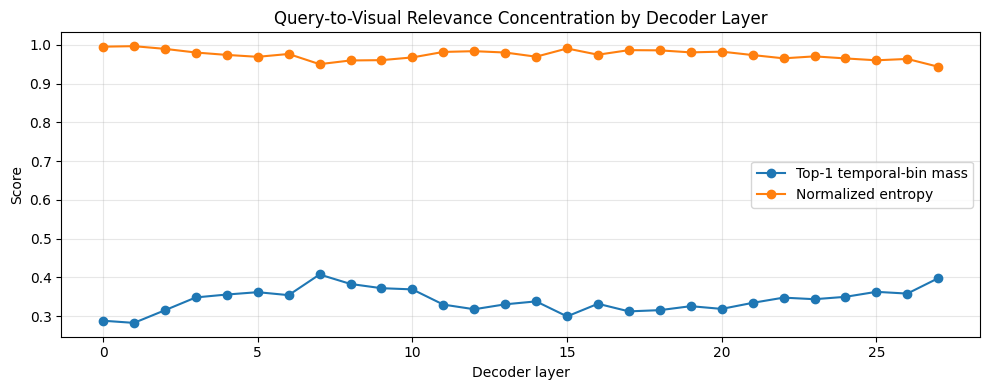

In [76]:
import json, glob, statistics
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

out = "outputs/experiment1_qwen_video_aware_low_f8"
files = [f for f in glob.glob(out + "/*.json") if not f.endswith("summary.json")]
data = [json.load(open(f)) for f in files]

L = len(data[0]["relevance"]["normalized_frame_scores"])
top1 = [
    statistics.mean(max(d["relevance"]["normalized_frame_scores"][i]) for d in data)
    for i in range(L)
]
entropy = [
    statistics.mean(d["relevance"]["concentration_by_layer"][i]["normalized_entropy"] for d in data)
    for i in range(L)
]

plt.figure(figsize=(10,4))
plt.plot(range(L), top1, marker="o", label="Top-1 temporal-bin mass")
plt.plot(range(L), entropy, marker="o", label="Normalized entropy")
plt.xlabel("Decoder layer")
plt.ylabel("Score")
plt.title("Query-to-Visual Relevance Concentration by Decoder Layer")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(out + "/layer_concentration.png", dpi=200)
plt.show()

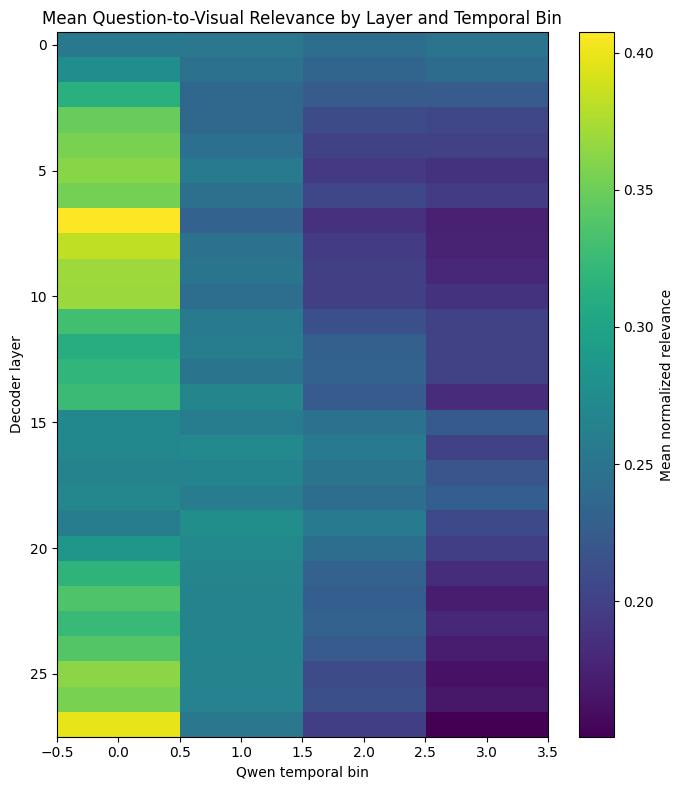

In [77]:
frame_scores = np.array([
    [
        statistics.mean(d["relevance"]["normalized_frame_scores"][i][j] for d in data)
        for j in range(len(data[0]["relevance"]["normalized_frame_scores"][i]))
    ]
    for i in range(L)
])

plt.figure(figsize=(7,8))
plt.imshow(frame_scores, aspect="auto", cmap="viridis")
plt.colorbar(label="Mean normalized relevance")
plt.xlabel("Qwen temporal bin")
plt.ylabel("Decoder layer")
plt.title("Mean Question-to-Visual Relevance by Layer and Temporal Bin")
plt.tight_layout()
plt.savefig(out + "/layer_temporal_heatmap.png", dpi=200)
plt.show()

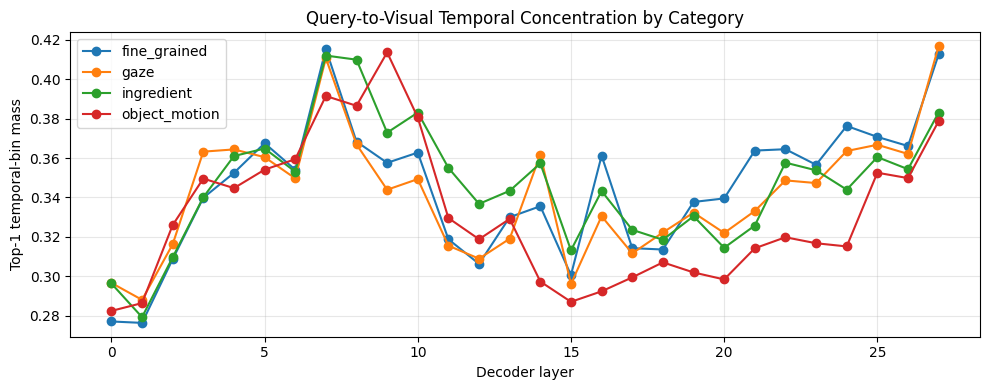

In [78]:
by_cat = defaultdict(list)
for d in data:
    by_cat[d["category"]].append(d)

plt.figure(figsize=(10,4))
for cat, items in sorted(by_cat.items()):
    cat_top1 = [
        statistics.mean(max(d["relevance"]["normalized_frame_scores"][i]) for d in items)
        for i in range(L)
    ]
    plt.plot(range(L), cat_top1, marker="o", label=cat)

plt.xlabel("Decoder layer")
plt.ylabel("Top-1 temporal-bin mass")
plt.title("Query-to-Visual Temporal Concentration by Category")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(out + "/category_layer_concentration.png", dpi=200)
plt.show()